<a href="https://colab.research.google.com/github/Kashu29/kashsish/blob/main/Alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Activation, Dropout,BatchNormalization

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [2]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()
#Normalise pixel values
X_train=X_train.astype('float32')/255
X_test=X_test.astype('float32')/255

# one-hot encode the labels
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [3]:
X_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [4]:
from ast import Str
model = Sequential()
#layer 1
model.add(Conv2D(96, kernel_size=(3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#layer 2
model.add(Conv2D(256, kernel_size= (3,3),strides=(1,1), input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

#layer 3
model.add(Conv2D(96, kernel_size= (3,3),strides=(1,1) ,input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))

#layer 4
model.add(Conv2D(96, kernel_size= (3,3),strides=(1,1) ,input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))

#layer 5
model.add(Conv2D(256, kernel_size= (3,3),strides=(1,1) ,input_shape=(32,32,3),padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# flatten
model.add(Flatten())

#fully connected layer 1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

#output layer
model.add(Dense(10))
model.add(Activation('softmax'))

/tmp/ipykernel_2040/2687205865.py:1: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  from ast import Str
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [6]:
history = model.fit(X_train,y_train,batch_size=128,epochs=15 , validation_split=0.2,verbose=1)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.4658 - loss: 1.5556 - val_accuracy: 0.1515 - val_loss: 7.1300
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6310 - loss: 1.0452 - val_accuracy: 0.4540 - val_loss: 1.6052
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7049 - loss: 0.8385 - val_accuracy: 0.6250 - val_loss: 1.0643
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7612 - loss: 0.6885 - val_accuracy: 0.5976 - val_loss: 1.3020
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8004 - loss: 0.5731 - val_accuracy: 0.6952 - val_loss: 0.9585
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8355 - loss: 0.4660 - val_accuracy: 0.6825 - val_loss: 1.0957
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8660 - loss: 0.3816 - val_accuracy: 0.7266 - val_loss: 0.9124
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8883 - loss: 0.3190 - val_acc

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7775 - loss: 1.1349
Test accuracy: 0.7774999737739563


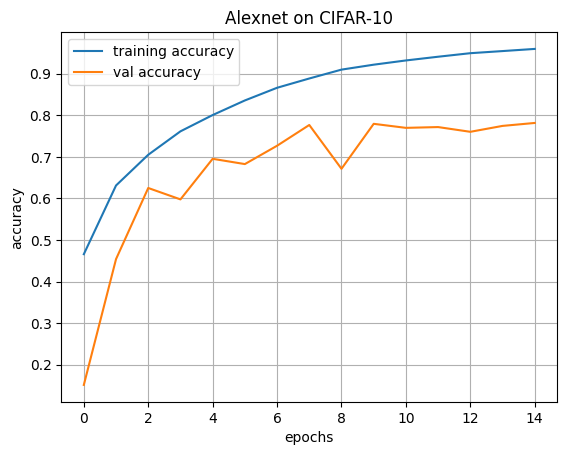

In [9]:
plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label = 'val accuracy')
plt.title('Alexnet on CIFAR-10')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()